In [2]:
# this notebook run locally with the data in csvs rom wayfinder
import pandas as pd

In [3]:
# Data ops' output
# Testing just the first 5 rows and columns of the Candidates.csv file
df_test = pd.read_csv("MCZ-2863/Candidates.csv", nrows=5)
df_test.columns

Index(['WinnowCandidateKey', 'CreatedDate', 'UpdatedDate', 'NPI',
       'ProfilePictureLink', 'FirstName', 'MiddleName', 'LastName', 'NickName',
       'FullName', 'PhysicianType', 'Degree', 'Category', 'State', 'City',
       'Address', 'PhoneNumber1', 'FaxNumber', 'ZipCode', 'Experience',
       'Educations', 'Certifications', 'AwardsHonors', 'Publications',
       'LicensureData', 'BoardCertifications', 'EducationTrainingLocation',
       'EducationTrainingDate', 'EducationTrainingYears', 'ExperienceBinned',
       'Email', 'IsActiveFlag', 'InactiveAt', 'Gender', 'PrimaryHospitalIDs',
       'PhysicianGroupID', 'HospitalHistoryAffiliation', 'ChurnScore',
       'Latitude', 'Longitude', 'TaxonomyCode', 'PhysicianRole', 'Speciality',
       'SubSpeciality', 'ResidencyTrainingLocation', 'ResidencyTrainingDate',
       'ResidencyTrainingYears', 'PublicationConnectionNPI',
       'CandidateValidEmail', 'MedicalCode'],
      dtype='object')

In [4]:
df_candidates = pd.read_csv("MCZ-2863/Candidates.csv", usecols=["NPI", "HospitalHistoryAffiliation" ], dtype={"NPI": str, "HospitalHistoryAffiliation": str} )

In [5]:
df_candidates[df_candidates.duplicated(subset=["NPI"]) == True].sort_values(by="NPI")

,NPI,HospitalHistoryAffiliation


In [6]:
df_candidates = df_candidates.drop_duplicates(subset=["NPI"])
df_candidates

,NPI,HospitalHistoryAffiliation
0,1780724997,NaN
1,1427150432,"[[""1245266956"",201501]]"
2,1215192984,NaN
3,1952566630,"[[""1174652614"",201606]]"
4,1154438141,"[[""1356765556"",201501], [""1699716027"",201602],..."
...,...,...
6218276,1346923679,NaN
6218277,1841368438,NaN
6218278,1699140251,NaN
6218279,1336499003,NaN


In [7]:
from ast import literal_eval

def find_max_affiliation_date(row):
    from ast import literal_eval
    import pandas as pd
    if pd.isna(row["HospitalHistoryAffiliation"]):
        return None
    affiliations = literal_eval(row["HospitalHistoryAffiliation"])
    max_date = None
    if len(affiliations) == 0:
        return None
    try:
        return pd.to_datetime(affiliations[-1][1], format="%Y%m", errors='coerce')
    except:
        print(f"Could not parse date: {affiliations[-1][1]}")
        return None


In [8]:
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)
from tqdm import tqdm

tqdm.pandas()

df_candidates['max_affiliation_date'] = df_candidates.parallel_apply(find_max_affiliation_date, axis=1)

INFO: Pandarallel will run on 14 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [9]:
df_candidates['max_affiliation_date'].describe()


count                          2166235
mean     2021-12-27 22:50:27.364620032
min                2013-10-01 00:00:00
25%                2019-10-01 00:00:00
50%                2023-02-01 00:00:00
75%                2024-12-01 00:00:00
max                2025-12-01 00:00:00
Name: max_affiliation_date, dtype: object

<Axes: >

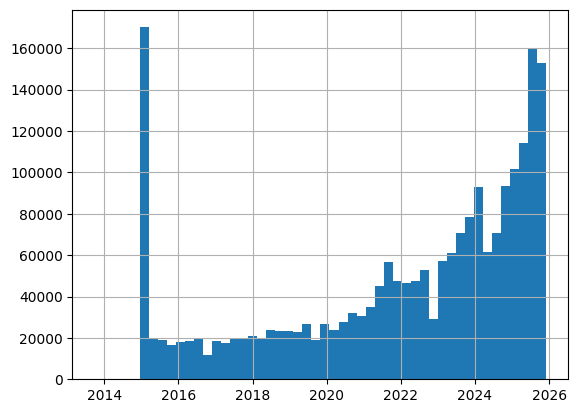

In [10]:
df_candidates["max_affiliation_date"].hist(bins=50)

In [11]:
# get top 10000 of max_affiliation_date
# because we want providers with a lot of claims to work with
df_recent_changes = df_candidates.nlargest(10000, 'max_affiliation_date')

In [12]:
df_recent_changes

,NPI,HospitalHistoryAffiliation,max_affiliation_date
13648,1316615115,"[[""1770536120"",202307], [""1215969787"",202402],...",2025-12-01
14733,1639112683,"[[""1023103819"",201501], [""1154669331"",201502],...",2025-12-01
22268,1740214626,"[[""1942228655"",201501], [""1487270492"",202205],...",2025-12-01
26421,1619133238,"[[""1023030160"",201501], [""1396829222"",201510],...",2025-12-01
30485,1659368793,"[[""1467491837"",201501], [""1912447418"",202501],...",2025-12-01
...,...,...,...
780502,1386822690,"[[""1821159195"",201503], [""1124032461"",201602],...",2025-11-01
780526,1578762902,"[[""1689772592"",201604], [""1952476665"",201611],...",2025-11-01
780552,1639344534,"[[""1801851258"",201501], [""1760568752"",202404],...",2025-11-01
780654,1629247994,"[[""1073568754"",202104], [""1710915756"",202303],...",2025-11-01


In [13]:
df_recent_changes["NPI"].to_csv("recent_changes_npis.csv", index=False)

# compare the DataOps output to output from Kythera

In [14]:
def format_affiliations(affiliation_str):
    from ast import literal_eval
    import pandas as pd
    if pd.isna(affiliation_str):
        return ""
    affiliations = literal_eval(affiliation_str)
    formatted_affiliations = []
    for affiliation in affiliations:
        if len(affiliation) == 2:
            formatted_affiliations.append({
                "HOSPITAL_NPI":affiliation[0],
                "Month_Year":affiliation[1]
            })
    return formatted_affiliations


In [15]:
def find_affiliation_differences(row):
    import pandas as pd
    affiliations_dataops = row["Historic_Affiliation_Output"]
    affiliations_kythera = row["Historic_Affiliation_Kythera"]

    # Extract Hospital NPIs
    npis_dataops = set([aff["HOSPITAL_NPI"] for aff in affiliations_dataops])
    npis_kythera = set([aff["HOSPITAL_NPI"] for aff in affiliations_kythera])

    # Get common and exclusive NPIs
    common_npis = npis_dataops & npis_kythera
    only_in_dataops = npis_dataops - npis_kythera
    only_in_kythera = npis_kythera - npis_dataops

    # Get min/max Month_Year for DataOps
    month_years_dataops = [aff["Month_Year"] for aff in affiliations_dataops]
    min_month_dataops = min(month_years_dataops) if month_years_dataops else None
    max_month_dataops = max(month_years_dataops) if month_years_dataops else None

    # Get min/max Month_Year for Kythera
    month_years_kythera = [aff["Month_Year"] for aff in affiliations_kythera]
    min_month_kythera = min(month_years_kythera) if month_years_kythera else None
    max_month_kythera = max(month_years_kythera) if month_years_kythera else None

    return pd.Series({
        "Common_Hospital_NPIs": common_npis,
        "Only_in_DataOps_NPIs": only_in_dataops,
        "Only_in_Kythera_NPIs": only_in_kythera,
        "Min_Month_Year_DataOps": min_month_dataops,
        "Max_Month_Year_DataOps": max_month_dataops,
        "Min_Month_Year_Kythera": min_month_kythera,
        "Max_Month_Year_Kythera": max_month_kythera,
        "Num_Common_NPIs": len(common_npis)
    })

In [16]:
from ast import literal_eval
def format_kythera_affiliations(row):
    if pd.isna(row):
        return []
    affiliations = literal_eval(row)
    affiliations = [{**a, "Month_Year": int(a["Month_Year"].replace("-",""))} for a in affiliations]
    return affiliations

In [17]:
def compare_query_output_vs_dataops(df_matched: pd.DataFrame):
    df_matched["Historic_Affiliation_Output"] = df_matched["HospitalHistoryAffiliation"].apply(format_affiliations)
    df_matched["Historic_Affiliation_Kythera"] = df_matched["Historic_Affiliation"].apply(format_kythera_affiliations)

    # Apply the function and concatenate the resulting columns
    affiliation_diffs = df_matched.apply(find_affiliation_differences, axis=1)
    df_matched = pd.concat([df_matched, affiliation_diffs], axis=1)

    return df_matched

## Old (v2) Output using LP query

In [18]:
df_kythera_v2 = pd.read_csv("MCZ-2863/10k_with_old_view.csv", dtype={"NPI": str} )

In [19]:
df_matched_old = pd.merge(df_recent_changes[["NPI","HospitalHistoryAffiliation"]], df_kythera_v2, on="NPI", how="inner", suffixes=('_dataops', '_kythera_v2'))

In [20]:
df_matched_old[["Historic_Affiliation", "HospitalHistoryAffiliation"]]

,Historic_Affiliation,HospitalHistoryAffiliation
0,"[{""HOSPITAL_NPI"":""1770536120"",""Month_Year"":""20...","[[""1770536120"",202307], [""1215969787"",202402],..."
1,"[{""HOSPITAL_NPI"":""1023103819"",""Month_Year"":""20...","[[""1023103819"",201501], [""1154669331"",201502],..."
2,"[{""HOSPITAL_NPI"":""1942228655"",""Month_Year"":""20...","[[""1942228655"",201501], [""1487270492"",202205],..."
3,"[{""HOSPITAL_NPI"":""1063670289"",""Month_Year"":""20...","[[""1023030160"",201501], [""1396829222"",201510],..."
4,"[{""HOSPITAL_NPI"":""1871608216"",""Month_Year"":""20...","[[""1467491837"",201501], [""1912447418"",202501],..."
...,...,...
9995,"[{""HOSPITAL_NPI"":""1821159195"",""Month_Year"":""20...","[[""1821159195"",201503], [""1124032461"",201602],..."
9996,"[{""HOSPITAL_NPI"":""1689772592"",""Month_Year"":""20...","[[""1689772592"",201604], [""1952476665"",201611],..."
9997,"[{""HOSPITAL_NPI"":""1558493908"",""Month_Year"":""20...","[[""1801851258"",201501], [""1760568752"",202404],..."
9998,"[{""HOSPITAL_NPI"":""1154375178"",""Month_Year"":""20...","[[""1073568754"",202104], [""1710915756"",202303],..."


In [21]:
df_matched_old = compare_query_output_vs_dataops(df_matched_old)

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
df_matched_old

,NPI,HospitalHistoryAffiliation,Historic_Affiliation,Affiliation_count,Historic_Affiliation_Output,Historic_Affiliation_Kythera,Common_Hospital_NPIs,Only_in_DataOps_NPIs,Only_in_Kythera_NPIs,Min_Month_Year_DataOps,Max_Month_Year_DataOps,Min_Month_Year_Kythera,Max_Month_Year_Kythera,Num_Common_NPIs
0,1316615115,"[[""1770536120"",202307], [""1215969787"",202402], [""1770536120"",202408], [""1538522412"",202512]]","[{""HOSPITAL_NPI"":""1770536120"",""Month_Year"":""2023-07""},{""HOSPITAL_NPI"":""1215969787"",""Month_Year"":""2024-02""},{""HOSPITAL_NPI"":""1770536120"",""Month_Year"":""2024-08""},{""HOSPITAL_NPI"":""1215969787"",""Month_Year"":""2025-10""},{""HOSPITAL_NPI"":""1235294232"",""Month_Year"":""2025-12""}]",5,"[{'HOSPITAL_NPI': '1770536120', 'Month_Year': 202307}, {'HOSPITAL_NPI': '1215969787', 'Month_Year': 202402}, {'HOSPITAL_NPI': '1770536120', 'Month_Year': 202408}, {'HOSPITAL_NPI': '1538522412', 'Month_Year': 202512}]","[{'HOSPITAL_NPI': '1770536120', 'Month_Year': 202307}, {'HOSPITAL_NPI': '1215969787', 'Month_Year': 202402}, {'HOSPITAL_NPI': '1770536120', 'Month_Year': 202408}, {'HOSPITAL_NPI': '1215969787', 'Month_Year': 202510}, {'HOSPITAL_NPI': '1235294232', 'Month_Year': 202512}]","{1770536120, 1215969787}",{1538522412},{1235294232},202307,202512,202307,202512,2
1,1639112683,"[[""1023103819"",201501], [""1154669331"",201502], [""1932294725"",201504], [""1154669331"",201512], [""1023103819"",201606], [""1154669331"",201704], [""1811153349"",201705], [""1154669331"",201706], [""1013357110"",201709], [""1154669331"",201710], [""1023103819"",201801], [""1013357110"",201804], [""1023103819"",201805], [""1790123768"",202006], [""1013196625"",202012], [""1770104481"",202102], [""1013196625"",202104], [""1518347921"",202109], [""1013196625"",202201], [""1093890634"",202204], [""1518347921"",202206], [""1013196625"",202207], [""1093890634"",202210], [""1518347921"",202305], [""1093890634"",202306], [""1467491837"",202405], [""1518347921"",202408], [""1093890634"",202410], [""1518347921"",202506], [""1093890634"",202507], [""1518347921"",202509], [""1093890634"",202512]]","[{""HOSPITAL_NPI"":""1023103819"",""Month_Year"":""2015-01""},{""HOSPITAL_NPI"":""1154669331"",""Month_Year"":""2015-02""},{""HOSPITAL_NPI"":""1023103819"",""Month_Year"":""2019-07""},{""HOSPITAL_NPI"":""1790123768"",""Month_Year"":""2020-06""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2020-12""},{""HOSPITAL_NPI"":""1770104481"",""Month_Year"":""2021-02""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2021-04""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2021-09""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2022-01""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2022-02""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2022-04""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2022-06""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2022-07""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2022-08""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2022-09""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2022-10""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2022-12""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2023-02""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2023-03""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2023-06""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2024-02""},{""HOSPITAL_NPI"":""1467491837"",""Month_Year"":""2024-05""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2024-08""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2024-10""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2025-06""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2025-12""}]",26,"[{'HOSPITAL_NPI': '1023103819', 'Month_Year': 201501}, {'HOSPITAL_NPI': '1154669331', 'Month_Year': 201502}, {'HOSPITAL_NPI': '1932294725', 'Month_Year': 201504}, {'HOSPITAL_NPI': '1154669331', 'Month_Year': 201512}, {'HOSPITAL_NPI': '1023103819', 'Month_Year': 201606}, {'HOSPITAL_NPI': '

## new (V3) output vs kythera

In [23]:
df_kythera_v3 = pd.read_csv("MCZ-2863/10k_with_new_view.csv", dtype={"NPI": str} )

In [24]:
df_matched_new = pd.merge(df_recent_changes[["NPI","HospitalHistoryAffiliation"]], df_kythera_v3, on="NPI", how="inner", suffixes=('_dataops', '_kythera_v3'))

In [25]:
df_matched_new = compare_query_output_vs_dataops(df_matched_new)

In [26]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
df_matched_new

,NPI,HospitalHistoryAffiliation,Historic_Affiliation,Affiliation_count,Historic_Affiliation_Output,Historic_Affiliation_Kythera,Common_Hospital_NPIs,Only_in_DataOps_NPIs,Only_in_Kythera_NPIs,Min_Month_Year_DataOps,Max_Month_Year_DataOps,Min_Month_Year_Kythera,Max_Month_Year_Kythera,Num_Common_NPIs
0,1316615115,"[[""1770536120"",202307], [""1215969787"",202402], [""1770536120"",202408], [""1538522412"",202512]]","[{""HOSPITAL_NPI"":""1770536120"",""Month_Year"":""2023-07""},{""HOSPITAL_NPI"":""1215969787"",""Month_Year"":""2024-02""},{""HOSPITAL_NPI"":""1770536120"",""Month_Year"":""2024-08""},{""HOSPITAL_NPI"":""1215969787"",""Month_Year"":""2025-10""},{""HOSPITAL_NPI"":""1235294232"",""Month_Year"":""2025-12""}]",5,"[{'HOSPITAL_NPI': '1770536120', 'Month_Year': 202307}, {'HOSPITAL_NPI': '1215969787', 'Month_Year': 202402}, {'HOSPITAL_NPI': '1770536120', 'Month_Year': 202408}, {'HOSPITAL_NPI': '1538522412', 'Month_Year': 202512}]","[{'HOSPITAL_NPI': '1770536120', 'Month_Year': 202307}, {'HOSPITAL_NPI': '1215969787', 'Month_Year': 202402}, {'HOSPITAL_NPI': '1770536120', 'Month_Year': 202408}, {'HOSPITAL_NPI': '1215969787', 'Month_Year': 202510}, {'HOSPITAL_NPI': '1235294232', 'Month_Year': 202512}]","{1770536120, 1215969787}",{1538522412},{1235294232},202307,202512,202307,202512,2
1,1639112683,"[[""1023103819"",201501], [""1154669331"",201502], [""1932294725"",201504], [""1154669331"",201512], [""1023103819"",201606], [""1154669331"",201704], [""1811153349"",201705], [""1154669331"",201706], [""1013357110"",201709], [""1154669331"",201710], [""1023103819"",201801], [""1013357110"",201804], [""1023103819"",201805], [""1790123768"",202006], [""1013196625"",202012], [""1770104481"",202102], [""1013196625"",202104], [""1518347921"",202109], [""1013196625"",202201], [""1093890634"",202204], [""1518347921"",202206], [""1013196625"",202207], [""1093890634"",202210], [""1518347921"",202305], [""1093890634"",202306], [""1467491837"",202405], [""1518347921"",202408], [""1093890634"",202410], [""1518347921"",202506], [""1093890634"",202507], [""1518347921"",202509], [""1093890634"",202512]]","[{""HOSPITAL_NPI"":""1023103819"",""Month_Year"":""2015-01""},{""HOSPITAL_NPI"":""1154669331"",""Month_Year"":""2015-03""},{""HOSPITAL_NPI"":""1023103819"",""Month_Year"":""2019-07""},{""HOSPITAL_NPI"":""1790123768"",""Month_Year"":""2020-06""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2020-12""},{""HOSPITAL_NPI"":""1770104481"",""Month_Year"":""2021-02""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2021-04""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2021-09""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2021-10""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2021-11""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2022-01""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2022-02""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2022-04""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2022-06""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2022-07""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2022-08""},{""HOSPITAL_NPI"":""1013196625"",""Month_Year"":""2022-09""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2022-10""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2022-12""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2023-02""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2023-05""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2023-06""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2024-02""},{""HOSPITAL_NPI"":""1467491837"",""Month_Year"":""2024-05""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2024-08""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2024-10""},{""HOSPITAL_NPI"":""1518347921"",""Month_Year"":""2025-06""},{""HOSPITAL_NPI"":""1093890634"",""Month_Year"":""2025-12""}]",28,"[{'HOSPITAL_NPI': '1023103819', 'Month_Year': 201501}, {'HOSPITAL_NPI': '1154669331', 'Month_Year': 201502}, {'HOSPITAL_NPI': '1932294725', 'Month_Year': 201504}, {'HO